In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Keep required columns
df = df[["tweet_clean", "class"]].dropna()
X = df["tweet_clean"].astype(str)
y = df["class"].astype(int)

# Train/validation/test split (70/15/15), stratified by class
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

# Baseline models with TF-IDF
models = {
    "SVM": LinearSVC(),
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=None),
    "RandomForest": RandomForestClassifier(n_estimators=100, n_jobs=None)
}

baseline_predictions = {}
baseline_results = []

for name, clf in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )),
        ("clf", clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    baseline_predictions[name] = {y_test.name: y_test, "y_pred": y_pred}

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted")
    })

    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Train size: 17348
Validation size: 3717
Test size: 3718

=== SVM ===
Accuracy: 0.8932
Macro F1: 0.7066
                    precision    recall  f1-score   support

       hate_speech     0.5327    0.2664    0.3551       214
offensive_language     0.9234    0.9510    0.9370      2879
           neither     0.8142    0.8416    0.8277       625

          accuracy                         0.8932      3718
         macro avg     0.7568    0.6863    0.7066      3718
      weighted avg     0.8826    0.8932    0.8852      3718


=== LogisticRegression ===
Accuracy: 0.8956
Macro F1: 0.6783
                    precision    recall  f1-score   support

       hate_speech     0.6792    0.1682    0.2697       214
offensive_language     0.9099    0.9677    0.9379      2879
           neither     0.8425    0.8128    0.8274       625

          accuracy                         0.8956      3718
         macro avg     0.8105    0.6496    0.6783      3718
      weighted avg     0.8853    0.8956    0.8808 

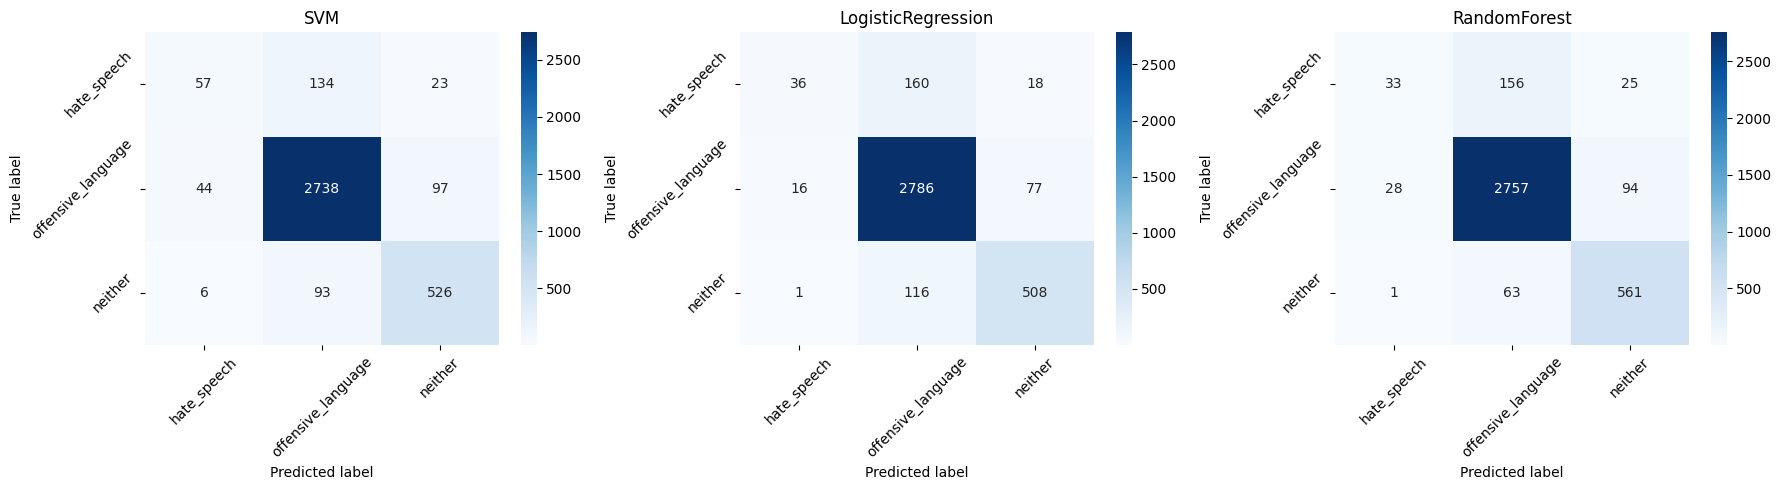


Baseline Model Comparison:


,Model,Accuracy,Macro F1,Weighted F1
0,SVM,0.893222,0.706621,0.885158
1,RandomForest,0.901291,0.680220,0.887535
2,LogisticRegression,0.895643,0.678305,0.880848



Classification Report for Best Model: SVM
                    precision    recall  f1-score   support

       hate_speech     0.5327    0.2664    0.3551       214
offensive_language     0.9234    0.9510    0.9370      2879
           neither     0.8142    0.8416    0.8277       625

          accuracy                         0.8932      3718
         macro avg     0.7568    0.6863    0.7066      3718
      weighted avg     0.8826    0.8932    0.8852      3718



In [7]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (name, results) in zip(axes, baseline_predictions.items()):
    cm = confusion_matrix(results[y_test.name], results["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_yticklabels(class_names, rotation=45)
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


comparison_df = pd.DataFrame(baseline_results).sort_values(by="Macro F1", ascending=False).reset_index(drop=True)

print("\nBaseline Model Comparison:")
display(comparison_df)

# Classification report for best model
best_model_name = comparison_df.loc[0, "Model"]
best_results = baseline_predictions[best_model_name]

print(f"\nClassification Report for Best Model: {best_model_name}")
print(classification_report(best_results[y_test.name], best_results["y_pred"], target_names=class_names, digits=4))